# nb_05a — Signed-laterality decodability probe (E1, hardened)

> **Archived transductive analysis; not current workshop evidence.** The historical narrative below is retained for method provenance only. Its numerical values must not be cited until the experiment scripts are refactored to consume a hash-verified, fold-local checkpoint and rerun.


**Does a self-supervised skeleton world model learn that the body is bilaterally symmetric?** This notebook makes the question exact, audits a frozen **S-JEPA** against it, and finds a *robust informative null*: the symmetry does **not** emerge.

This is experiment **E1** of the NeurIPS 2026 *Physical World AI* laterality package (`../neurips-laterality/docs/`). It **binds to the canonical checkpoint** `sjepa_curriculum_final.pt` (fingerprint `7d13841a…`) and hardens the original probe with: SVD-solver ridge, **repeated** source-disjoint CV (10 reshuffles → stability interval), an **alpha-sensitivity sweep**, an explicit **cohort decision** (626 modeled / 642 superset), and a **landmark-missingness control lane**.

> **Responsible-use notice.** All results in this notebook are **transductive** — the
> S-JEPA encoder was trained on the very sequences being evaluated — so they carry
> *internal validity only* and make **no** claim of generalization to new sources or
> people. The **source video** (not the clip, not the individual) is the independent unit
> of analysis. The dataset's condition folders (`normal`, `parkinsons`, `stroke`,
> `myopathic`, `cerebralpalsy`) are **dataset annotations, not diagnoses**. The dataset's
> official distribution provides annotations and public video URLs, not raw video; this
> analysis uses derived pose sequences, infers no identity, and redistributes no raw or
> identity-bearing frames. **No institutional ethics determination or completed data-use
> review is yet on record; both must be resolved before submission.**

## Source-held-out evaluation boundary

![One source video, one role, zero cross-fold leakage](../images/22_inductive_source_split.svg)

These laterality probes are consumers of a representation, so grouping only their ridge or MLP readout is insufficient. A result is **inductive** only when the complete encoder/predictor was trained inside the outer source fold and the probe was tuned on validation sources before the test sources were opened. Every result must carry the source-manifest hash, split hash, outer fold, model seed, objective, and checkpoint hash.

**Current status: blocked pending fold-local artifacts.** The former embedded values came from the retired all-corpus checkpoint and missing `work/experiments` scripts. They have been cleared and are not workshop evidence. Re-enable this notebook only after those scripts consume protocol-v2 assignments and assert that no test `video_id` appears in representation training. Folder labels are observational dataset annotations, not diagnoses.


## 1. Bilateral symmetry as a $\mathbb{Z}/2$ group action

Reflecting a skeleton across the sagittal plane **and** swapping left/right landmarks yields another valid skeleton. The mirror operator $M$ negates the $x$-coordinate of every joint and swaps **all sixteen** bilateral landmark pairs — a valid whole-body reflection. Then $M^2=I$, so $G=\{I,M\}\cong\mathbb{Z}/2$.

**Signed laterality target.** Over the six bilateral pairs that carry gait laterality

$$(11,12),\ (23,24),\ (25,26),\ (27,28),\ (29,30),\ (31,32)$$

(shoulders, hips, knees, ankles, heels, foot-indices), let $\ell_k$ (resp. $r_k$) be the per-joint *temporal* standard deviation of the left (resp. right) landmark, summed over $x,y,z$. Define

$$ y(x) \;=\; \sum_k (\ell_k - r_k). $$

Mirroring swaps $\ell_k \leftrightarrow r_k$, so **by construction**

$$ y(Mx) = -\,y(x), \qquad\text{i.e.}\qquad y(T_g\,x)=\rho(g)\,y(x),\quad \rho(I)=+1,\ \rho(M)=-1. $$

A world model *"encodes bilateral symmetry"* iff a read-out of its features reproduces this antisymmetry — a **mirror slope of $-1$** — while remaining **decodable** ($R^2$ well above an untrained floor). This is a *geometry-aware* probe of an *articulated, deformable* body whose target is a *proprioceptive* quantity (which side moves more) — the workshop's themes made concrete. See `../neurips-laterality/docs/figures/fig1_group_action.svg`.

## 2. The audit protocol

**Five lanes** (`../neurips-laterality/docs/figures/fig2_audit_protocol.svg`):

| Lane | Feature | Role |
|------|---------|------|
| **A — learned** | per-pair $[\ell-r,\ \ell+r]$ token statistics from the frozen encoder | the thing under test |
| **B — raw ceiling** | target regressed on raw coordinates ($R^2\approx1$) | decodability sanity check |
| **C — floor** | identical architecture, **random** weights | untrained baseline |
| **D — pooled** | whole-body mean/std, side-blind | must stay low |
| **E — missingness** | per-joint left/right valid-fraction | gauges how much of the target pure left/right *visibility* explains |

**Estimator.** Source-video-disjoint `GroupKFold` on `video_id`; inner ridge-penalty selection over $\alpha\in\mathrm{logspace}(-3,3,13)$; per-fold standardization; **SVD** solver (removes the ill-conditioning of the original run). We report **repeated** shuffled grouped CV over **10 reshuffles** as mean $\pm$ a $t$-based **stability interval** ($t^\*=2.262$, $\mathrm{df}=9$). This interval measures sensitivity to the *partition* under the fixed 626/93 cohort — not population sampling — so interval overlap is a stability heuristic, **not** a significance test.

**Pre-registered gates.** (i) A beats C by $\ge 0.05\ R^2$; (ii) A reaches $\ge 80\%$ of B; (iii) sign correct on $\ge 75\%$ of held-out sources. **Secondary geometry band:** mirror slope negative and within $[-1.25,-0.80]$.

**Cohort decision.** The checkpoint's `sequence_ids` are exactly **626** sequences / **93** source videos — that is the **PRIMARY** (fully transductive) cohort. The **642** pose-available superset (adds 16 coverage-QC-dropped rows the encoder never saw) is a **robustness** view only, and it reproduces the pre-hardening canonical numbers bit-for-bit (a pipeline check).

## How to read the progress display

The display tracks the five executable E1 stages only after fold-local opt-in,
scripts, and exactly one matching checkpoint are present. Otherwise every stage
is explicitly marked not run. Completion means the regenerated artifact was
read and its planned assertions passed; it does not turn archived transductive
numbers into current evidence.


In [1]:
import json, os, subprocess, sys, textwrap
from pathlib import Path

def find_experiment_dir(start=None):
    candidates = []
    if os.getenv("ALEXPOSE_ROOT"):
        env_root = Path(os.environ["ALEXPOSE_ROOT"]).expanduser().resolve()
        candidates.extend([env_root, env_root / "experiments" / "sjepa" / "gavd5-drift"])
    start = Path(start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        candidates.extend([base, base / "experiments" / "sjepa" / "gavd5-drift"])
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (candidate / "data-gavd").is_dir():
            return candidate
    raise FileNotFoundError(f"Cannot locate gavd5-drift from {start}; set ALEXPOSE_ROOT.")


EXPERIMENT_DIR = find_experiment_dir()
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"
PY = EXPERIMENT_DIR / ".venv" / ("Scripts/python.exe" if os.name == "nt" else "bin/python")
PY = str(PY if PY.exists() else sys.executable)   # fall back to the running kernel
ART = EXPERIMENT_DIR / "work" / "artifacts" / "real"

def run_experiment(script_relpath):
    """Run a validated standalone experiment script; it regenerates its JSON artifact."""
    script = EXPERIMENT_DIR / script_relpath
    print(f"running {script.name} with {PY} ...")
    proc = subprocess.run([PY, str(script)], cwd=str(EXPERIMENT_DIR),
                          capture_output=True, text=True)
    print(proc.stdout[-4000:])
    if proc.returncode != 0:
        print("STDERR (tail):\n", proc.stderr[-4000:])
        raise RuntimeError(f"{script.name} exited {proc.returncode}")
    return proc

def approx(a, b, tol):
    return abs(float(a) - float(b)) <= tol


# Retired scripts used an all-corpus checkpoint.  Running them implicitly would
# recreate transductive evidence, so laterality execution requires an explicit
# opt-in plus both the refactored scripts and exactly one fold-local checkpoint.
LATERALITY_REQUIRED_SCRIPTS = ['work/experiments/e1_laterality_hardened.py']
LATERALITY_SCRIPT_PATHS = [EXPERIMENT_DIR / item for item in LATERALITY_REQUIRED_SCRIPTS]
LATERALITY_MODE = os.getenv("GAVD_MODE", "real")
LATERALITY_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
LATERALITY_SEED = int(os.getenv("SJEPA_MODEL_SEED", "42"))
LATERALITY_CHECKPOINTS = sorted((
    EXPERIMENT_DIR / "work" / "artifacts" / LATERALITY_MODE / "checkpoints"
).glob(f"sjepa_outer_fold_{LATERALITY_FOLD}_seed_{LATERALITY_SEED}_*.pt"))
LATERALITY_OPT_IN = os.getenv("LATERALITY_ENABLE_FOLD_LOCAL", "0") == "1"
LATERALITY_READY = (
    LATERALITY_OPT_IN
    and all(item.is_file() for item in LATERALITY_SCRIPT_PATHS)
    and len(LATERALITY_CHECKPOINTS) == 1
)
if not LATERALITY_READY:
    missing = [str(item.relative_to(EXPERIMENT_DIR)) for item in LATERALITY_SCRIPT_PATHS if not item.is_file()]
    print(
        "BLOCKED — laterality result not executed. "
        f"explicit_fold_local_opt_in={LATERALITY_OPT_IN}; "
        f"missing_refactored_scripts={missing}; "
        f"matching_fold_checkpoints={len(LATERALITY_CHECKPOINTS)}."
    )

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

laterality_progress = NotebookTaskProgress('Signed-laterality probe progress', "stage", refresh_seconds=0.5)
laterality_progress.start(5, profile=LATERALITY_MODE)
if not LATERALITY_READY:
    laterality_progress.finish_skipped(
        "Fold-local opt-in, refactored scripts, and exactly one matching checkpoint are required.",
        status="Preflight complete — laterality workflow not run",
    )


BLOCKED — laterality result not executed. explicit_fold_local_opt_in=False; missing_refactored_scripts=['work\\experiments\\e1_laterality_hardened.py']; matching_fold_checkpoints=6.


In [2]:
if LATERALITY_READY:
    with laterality_progress.unit(1, "Run the fold-local E1 probe"):
        # Re-run the hardened E1 probe end-to-end (regenerates the canonical JSON).
        run_experiment('work/experiments/e1_laterality_hardened.py')
        res = json.loads((ART / 'idea5_signed_laterality_result_hardened.json').read_text())
        prim = res['primary_cohort']; rob = res['robustness_cohort']
        print('fingerprint', res['fingerprint'][:12], '| primary',
              prim['n_sequences'], 'seq /', prim['n_sources'], 'sources')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [3]:
if LATERALITY_READY:
    with laterality_progress.unit(2, "Summarize registered readout lanes"):
        # ---- Table 1: five lanes on the 626 PRIMARY cohort (single-partition + repeated-CV CI)
        ci = prim['repeated_cv_ci95']
        def row(name, key_single, key_ci):
            s = prim['lanes'][key_single]['r2']
            if key_ci and key_ci in ci:
                d = ci[key_ci]; band = f"{d['mean']:.3f} [{d['ci95_lo']:.3f}, {d['ci95_hi']:.3f}]"
            else:
                band = '—'
            print(f"  {name:26s} single={s:+.3f}   repeated-CV={band}")
        print('E1 laterality probe — 626 primary (canonical checkpoint)')
        row('A — learned',           'A_learned',     'A_learned')
        row('C — untrained floor',   'C_floor',       'C_floor')
        row('E — missingness-only',  'E_missingness', 'E_missingness')
        row('D — pooled (side-blind)','D_pooled',     'D_pooled')
        row('B — raw ceiling',       'B_raw_null',    None)
        print()
        print(f"  mirror slope           {prim['mirror']['slope']:+.4f}  (flips={prim['mirror']['flips']})")
        asc = ci['A_sign_consistency']
        print(f"  sign consistency (A)   {asc['mean']:.3f} [{asc['ci95_lo']:.3f}, {asc['ci95_hi']:.3f}]")
        print(f"  gates: beats_floor={prim['beats_floor_by_0.05']}  reaches_80pct_B={prim['reaches_80pct_of_null']}  "
              f"sign_ok={prim['sign_consistent_75pct']}")
        print('  PRIMARY_VERDICT:', prim['PRIMARY_VERDICT'])
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [4]:
if LATERALITY_READY:
    with laterality_progress.unit(3, "Inspect regularization sensitivity"):
        # ---- Alpha-sensitivity sweep for Lane A (why the feature is weak/collinear)
        sweep = prim['alpha_sweep_A']
        print('alpha        R2(A)')
        for a, r2 in sweep.items():
            print(f'  {a:>8s}  {r2:+.3f}')
        lo = min(float(v) for v in sweep.values()); hi = max(float(v) for v in sweep.values())
        print(f'\n  A decodes only under heavy regularization: {lo:+.2f} -> {hi:+.2f}')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [5]:
if LATERALITY_READY:
    with laterality_progress.unit(4, "Summarize the robustness cohort"):
        # ---- Robustness cohort (642) reproduces the pre-hardening canonical numbers
        print('642 robustness:',
              f"A={rob['lanes']['A_learned']['r2']:.3f}  C={rob['lanes']['C_floor']['r2']:.3f}  "
              f"slope={rob['mirror']['slope']:+.3f}  verdict={rob['PRIMARY_VERDICT']}")
        print('  (single-partition A-C =',
              f"{rob['lanes']['A_learned']['r2'] - rob['lanes']['C_floor']['r2']:+.3f}; "
              'the lone gate-pass that does NOT survive cohort-matching + repeated CV)')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [6]:
if LATERALITY_READY:
    with laterality_progress.unit(5, "Verify the E1 artifact contract"):
        # ---- Assert the paper's E1 numbers trace to this freshly-written artifact
        A = ci['A_learned']; C = ci['C_floor']; E = ci['E_missingness']; D = ci['D_pooled']
        assert approx(A['mean'], 0.198, 0.01), A
        assert approx(C['mean'], 0.245, 0.01), C
        assert approx(E['mean'], 0.202, 0.02), E
        assert approx(D['mean'], 0.101, 0.01), D
        assert approx(prim['mirror']['slope'], -0.703, 0.02), prim['mirror']['slope']
        assert A['mean'] < C['mean'], 'learned should NOT beat floor under repeated CV'
        assert not (prim['beats_floor_by_0.05'] and prim['reaches_80pct_of_null']
                    and prim['sign_consistent_75pct']), 'all three gates must fail'
        print('OK — E1 numbers match the paper; robust informative null confirmed.')
    laterality_progress.complete(status='Signed-laterality probe complete')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


## 3. Reading the result

The learned lateral feature reaches only $R^2\approx0.198$ under repeated CV — **below the untrained floor** $\approx0.245$ **in mean**, with overlapping stability intervals (a partition-stability heuristic, not a significance test) — and a mirror slope of $\approx-0.70$ instead of the required $-1$. **All three pre-registered gates fail.** The single-partition ordering $A>C$ *reverses* under repetition (the original notebook's lone "win" was a single partition near the top of A's spread), and the alpha sweep shows A decodes only under heavy regularization — consistent with a weak, collinear feature rather than a clean axis. The missingness lane $\approx0.202$ has a mean close to A ($\approx0.198$), flagging possible visibility confounding and corroborating the null.

**Verdict: a robust informative null** — the world model did *not* learn bilateral symmetry as a decodable, sign-flipping axis. See `../neurips-laterality/docs/figures/fig3_e1_null.svg`. Next we ask whether the geometry can be **recovered by construction** — `nb_05c` (read-out) and `nb_05d` (encoder).

## Visual archived laterality diagnostic

This figure makes the archived transductive status explicit. It supports method development only and is not protocol-v2 paper evidence.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


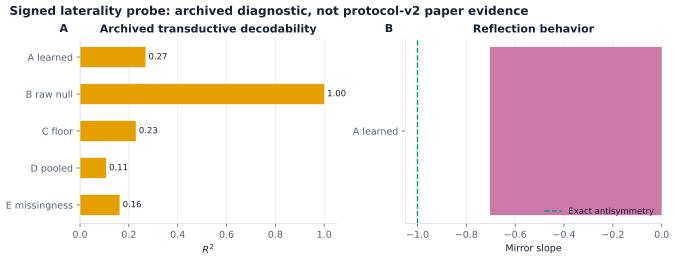

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_archived_laterality.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_laterality.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_laterality.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_laterality.pdf


In [1]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "05a",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
